# Model Evaluation: Confusion Matrix, Loss & Accuracy Curves

Comprehensive evaluation untuk paper akademis:
1. Confusion Matrix untuk setiap model
2. Training & Validation Loss Curves
3. Training & Validation Accuracy Curves
4. Per-class Accuracy Analysis

In [12]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report

# Add project root
sys.path.append('..')

from models.resnet_ghost import ghost_resnet18, ghost_resnet_small
from utils.dataloader import get_loaders

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# CIFAR-10 class names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

Device: cuda


## 1. Load Test Data

In [13]:
# Load CIFAR-10 test set
_, _, test_loader = get_loaders(batch_size=128, dataset='cifar10', num_workers=2)
print(f"Test samples: {len(test_loader.dataset)}")

Files already downloaded and verified
Files already downloaded and verified
Test samples: 10000


## 2. Helper Functions

In [14]:
def load_model_weights(model, weight_path):
    """Load weights handling various checkpoint formats"""
    checkpoint = torch.load(weight_path, map_location='cpu', weights_only=False)
    
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif 'model' in checkpoint:
        state_dict = checkpoint['model']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint
    
    # Filter profiling keys
    state_dict = {k: v for k, v in state_dict.items() 
                  if not k.endswith(('total_ops', 'total_params'))}
    model.load_state_dict(state_dict, strict=False)
    return model

def get_predictions(model, data_loader, device):
    """Get all predictions and labels"""
    model.eval()
    model.to(device)
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'{title} - Counts')
    
    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title(f'{title} - Normalized')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return cm

## 3. Confusion Matrix - Baseline Model

Baseline Accuracy: 95.23%
Saved: ../weights/visualization/confusion_matrix_baseline.png


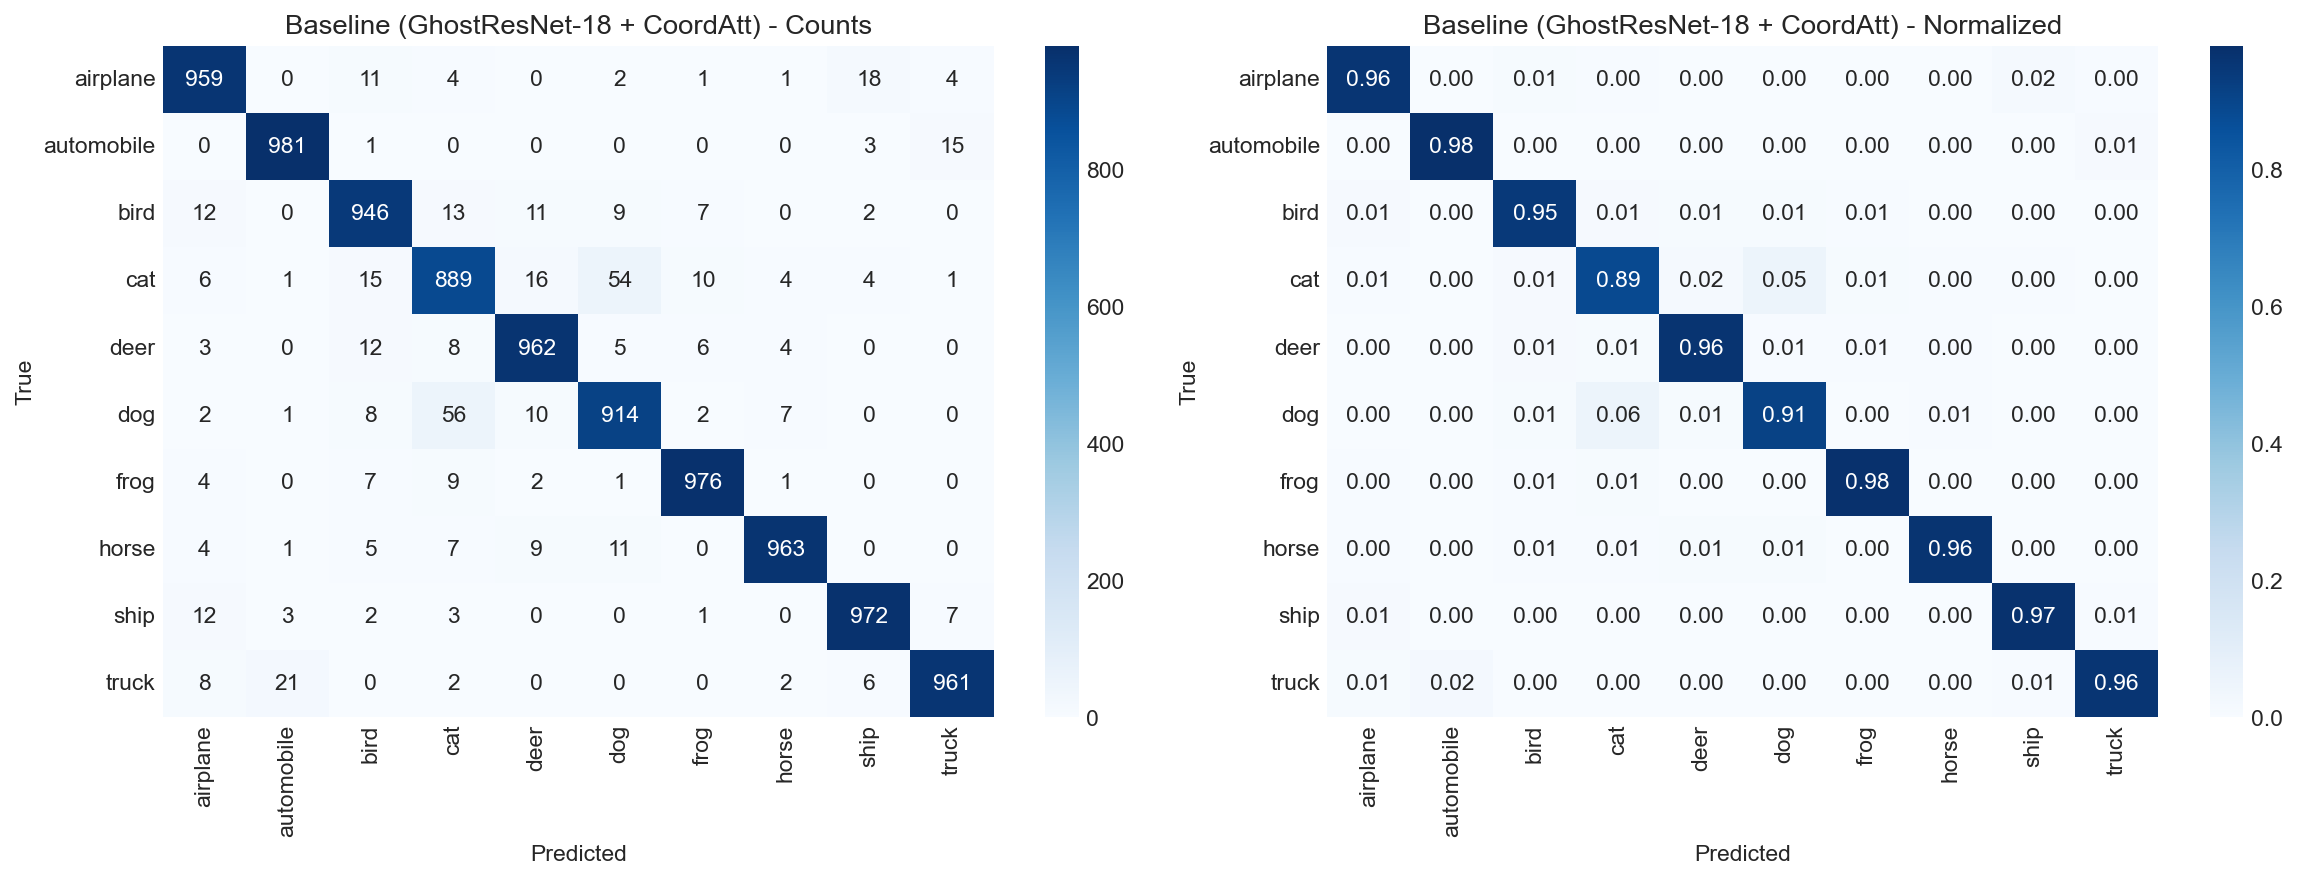

In [15]:
# Load Baseline Model
baseline_model = ghost_resnet18(num_classes=10, attention_type='coordinate')
baseline_model = load_model_weights(baseline_model, '../weights/baseline.pth')

# Get predictions
baseline_preds, labels, baseline_probs = get_predictions(baseline_model, test_loader, device)

# Accuracy
baseline_acc = 100 * np.mean(baseline_preds == labels)
print(f"Baseline Accuracy: {baseline_acc:.2f}%")

# Confusion Matrix
cm_baseline = plot_confusion_matrix(
    labels, baseline_preds, CLASS_NAMES,
    'Baseline (GhostResNet-18 + CoordAtt)',
    '../weights/visualization/confusion_matrix_baseline.png'
)

In [16]:
# Classification Report - Baseline
print("\nClassification Report - Baseline:")
print("="*60)
print(classification_report(labels, baseline_preds, target_names=CLASS_NAMES, digits=4))


Classification Report - Baseline:
              precision    recall  f1-score   support

    airplane     0.9495    0.9590    0.9542      1000
  automobile     0.9732    0.9810    0.9771      1000
        bird     0.9394    0.9460    0.9427      1000
         cat     0.8971    0.8890    0.8930      1000
        deer     0.9525    0.9620    0.9572      1000
         dog     0.9177    0.9140    0.9158      1000
        frog     0.9731    0.9760    0.9745      1000
       horse     0.9807    0.9630    0.9717      1000
        ship     0.9672    0.9720    0.9696      1000
       truck     0.9727    0.9610    0.9668      1000

    accuracy                         0.9523     10000
   macro avg     0.9523    0.9523    0.9523     10000
weighted avg     0.9523    0.9523    0.9523     10000



## 4. Confusion Matrix - Pruned Model

Pruned Model Accuracy: 93.00%
Saved: ../weights/visualization/confusion_matrix_pruned.png


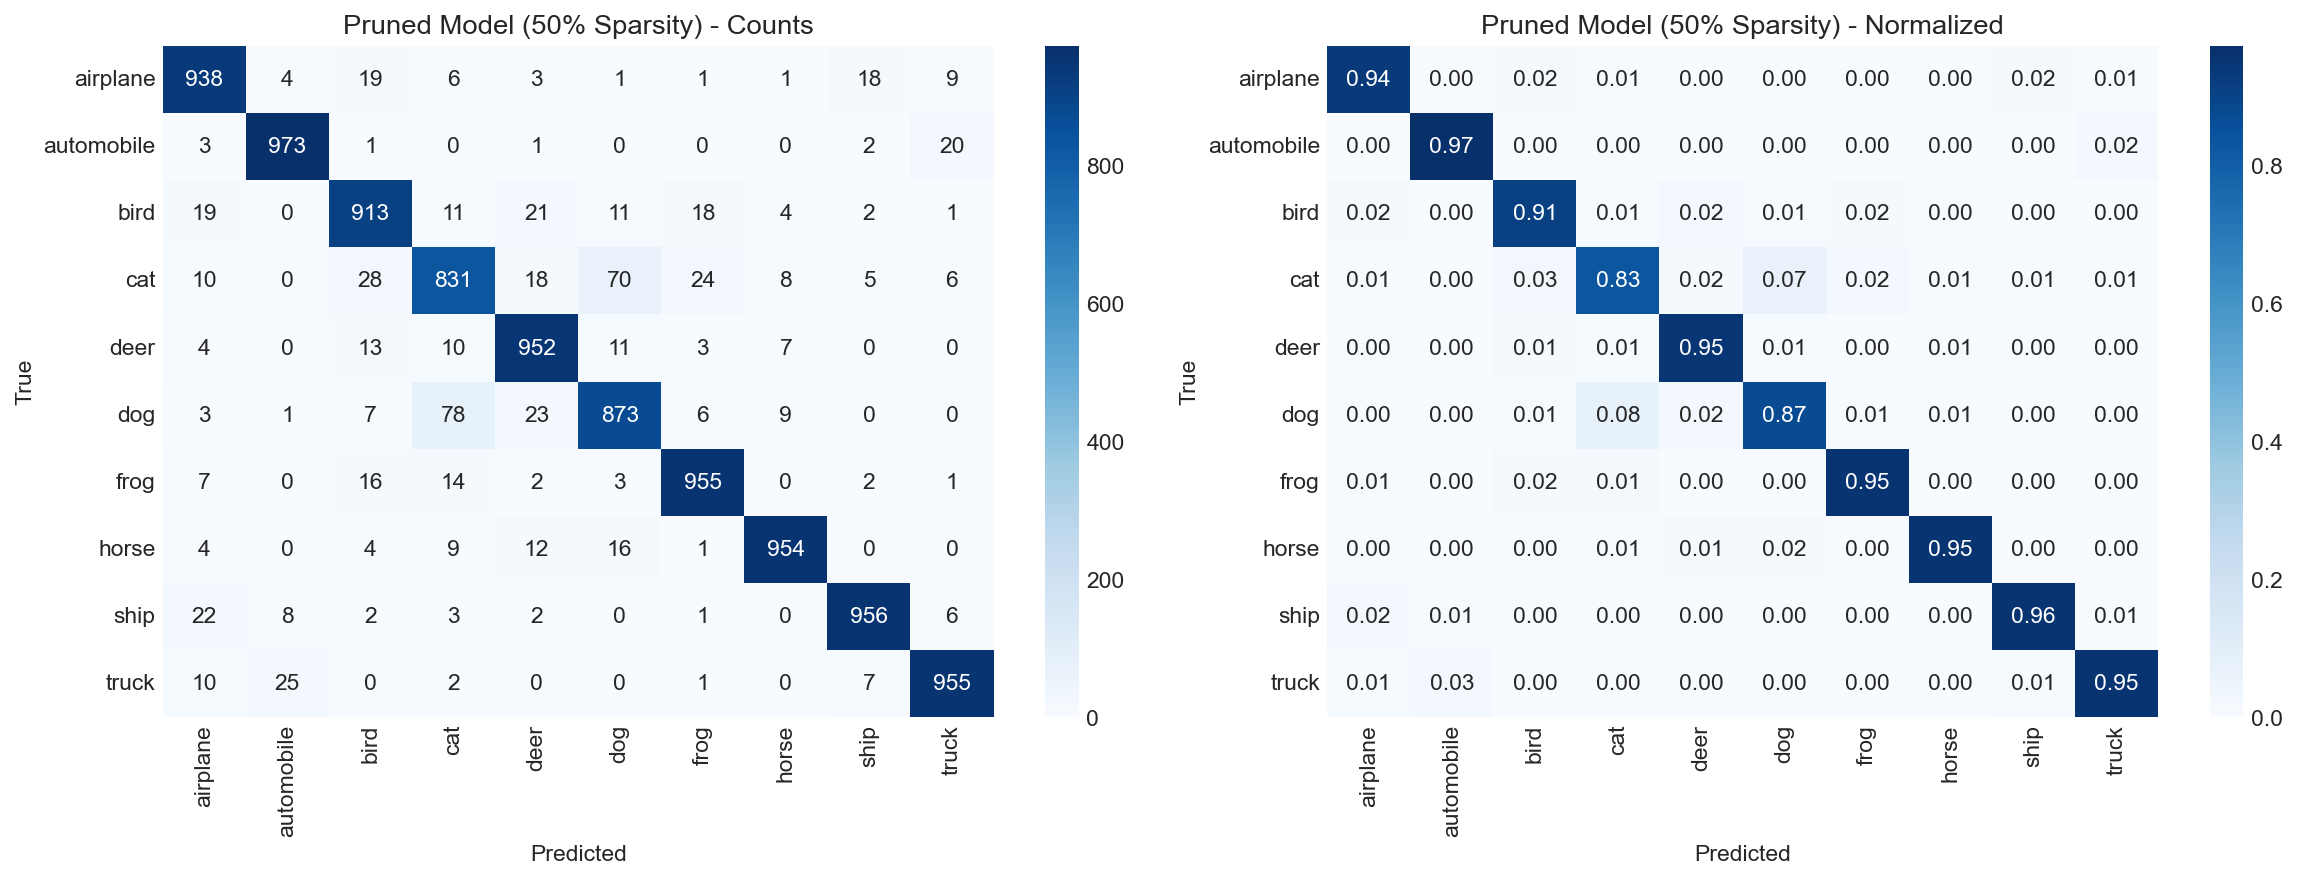

In [17]:
# Load Pruned Model
pruned_path = '../weights/pruning_experiments/pruning_structured_0.5_20260130_105549/pruned_model.pth'

if os.path.exists(pruned_path):
    pruned_model = ghost_resnet18(num_classes=10, attention_type='coordinate')
    pruned_model = load_model_weights(pruned_model, pruned_path)
    
    pruned_preds, _, _ = get_predictions(pruned_model, test_loader, device)
    pruned_acc = 100 * np.mean(pruned_preds == labels)
    print(f"Pruned Model Accuracy: {pruned_acc:.2f}%")
    
    cm_pruned = plot_confusion_matrix(
        labels, pruned_preds, CLASS_NAMES,
        'Pruned Model (50% Sparsity)',
        '../weights/visualization/confusion_matrix_pruned.png'
    )
else:
    print(f"Pruned model not found at {pruned_path}")

## 5. Confusion Matrix - Distilled Student

Distilled Student Accuracy: 93.74%
Saved: ../weights/visualization/confusion_matrix_distilled.png


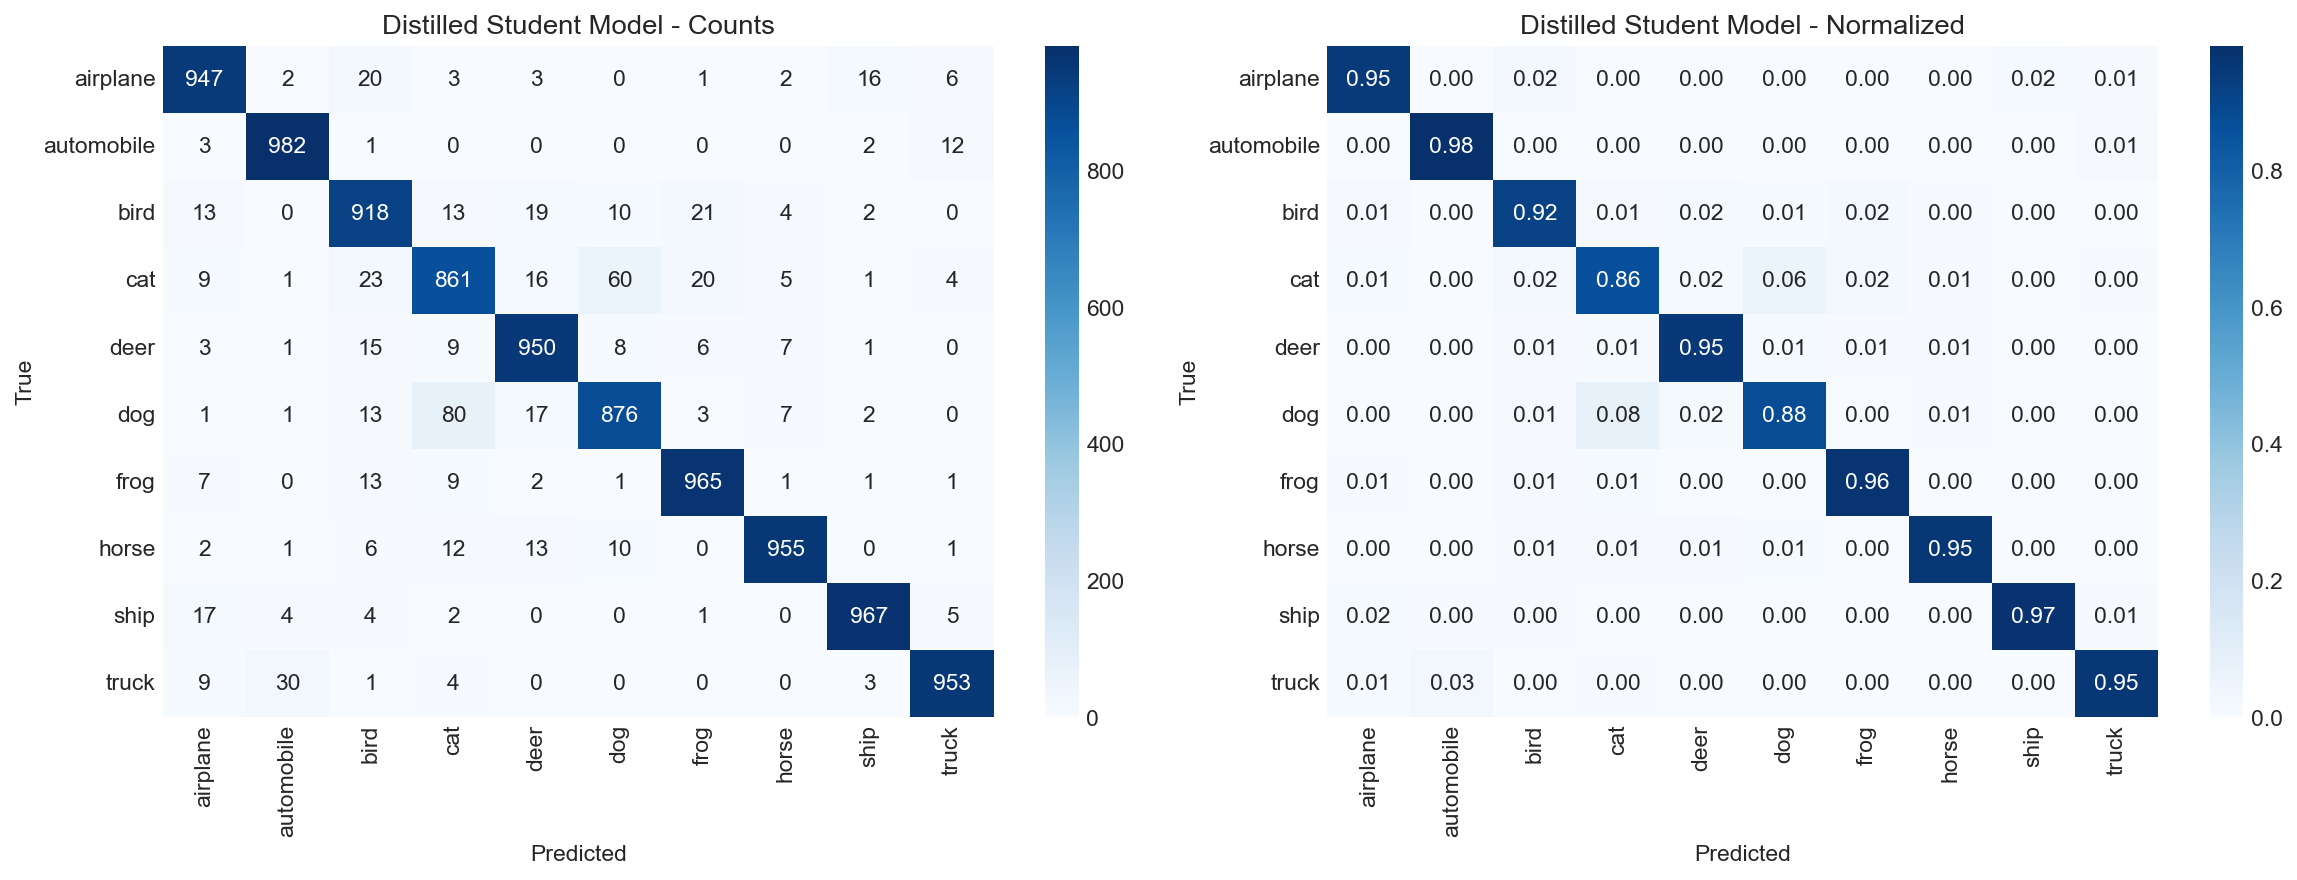

In [18]:
# Load Distilled Student
distilled_path = '../weights/distillation_experiments/distillation_ghost_resnet18_ghost_resnet_small_20260130_141604/experiment/best_model.pth'

if os.path.exists(distilled_path):
    student_model = ghost_resnet_small(num_classes=10, attention_type='coordinate')
    student_model = load_model_weights(student_model, distilled_path)
    
    student_preds, _, _ = get_predictions(student_model, test_loader, device)
    student_acc = 100 * np.mean(student_preds == labels)
    print(f"Distilled Student Accuracy: {student_acc:.2f}%")
    
    cm_student = plot_confusion_matrix(
        labels, student_preds, CLASS_NAMES,
        'Distilled Student Model',
        '../weights/visualization/confusion_matrix_distilled.png'
    )
else:
    print(f"Distilled model not found at {distilled_path}")

## 6. Confusion Matrix - Quantized Model

Quantized Model Accuracy: 95.22%
Saved: ../weights/visualization/confusion_matrix_quantized.png


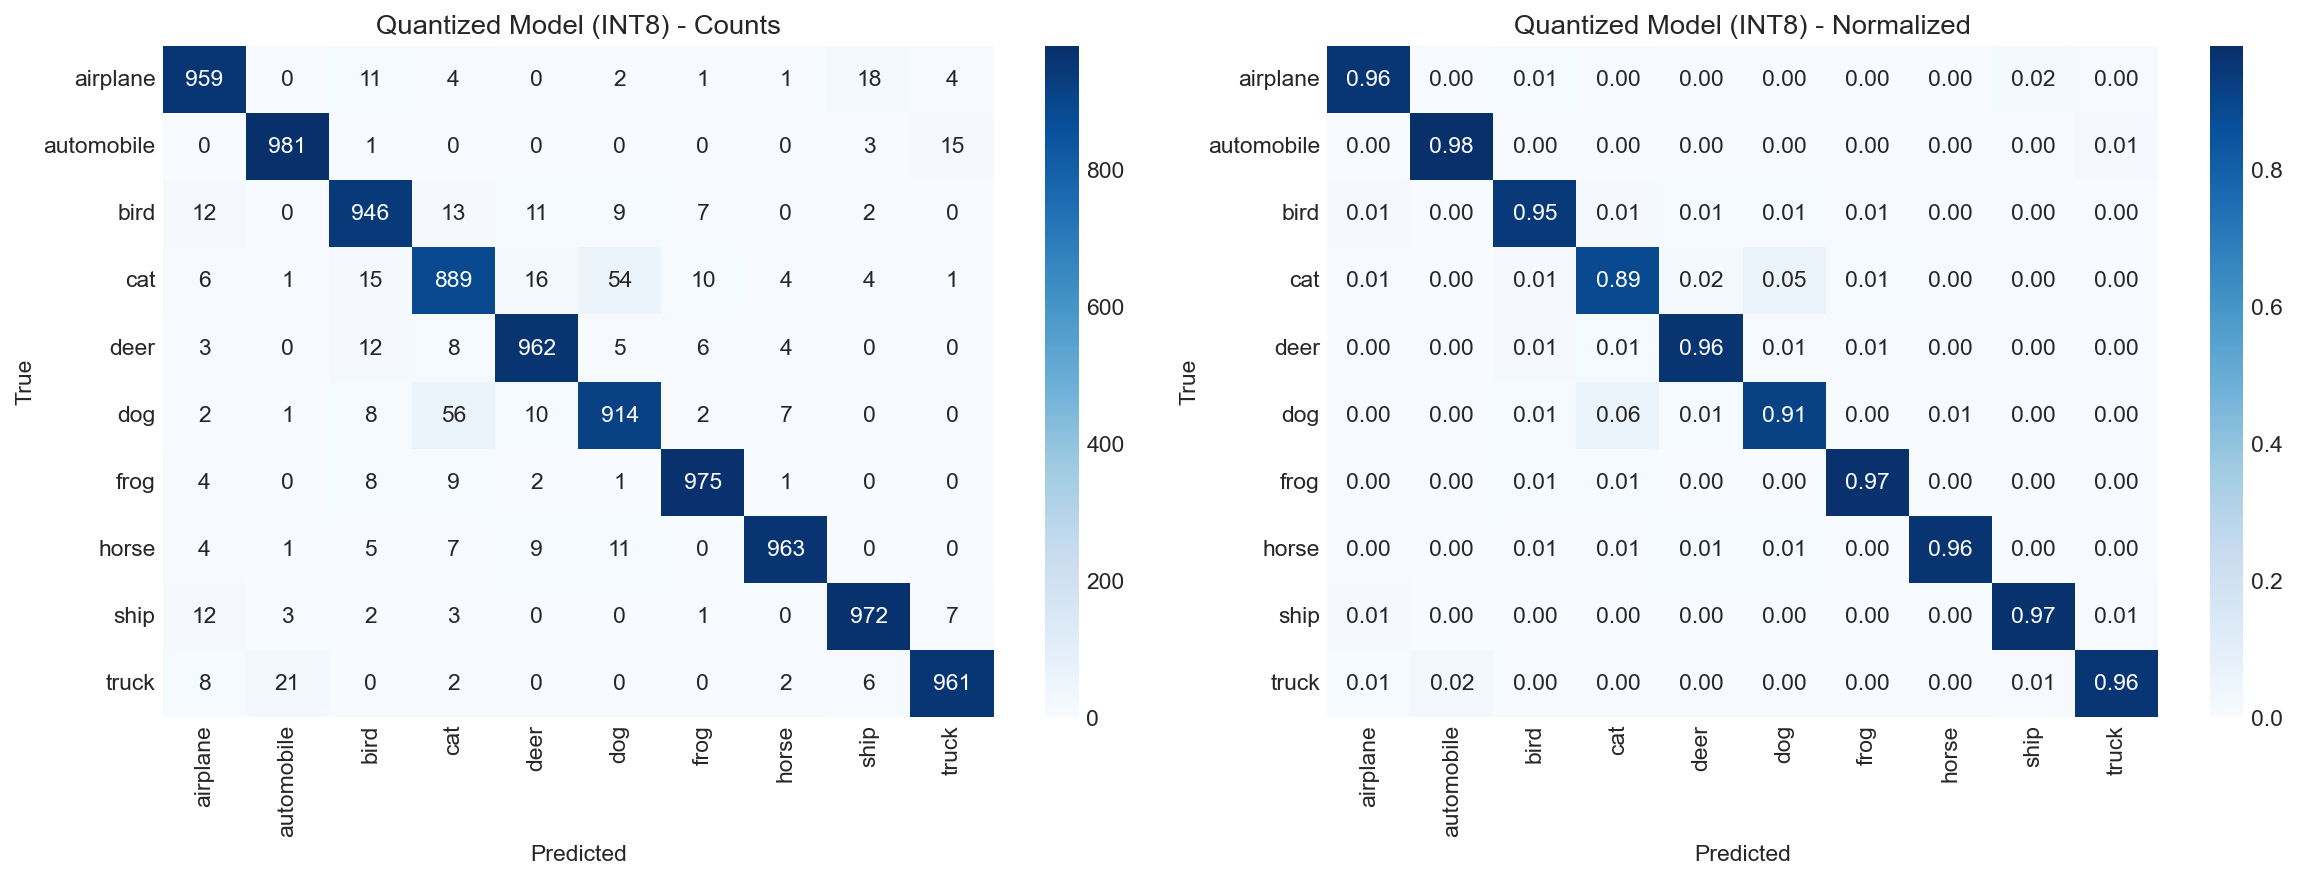

In [19]:
# Load Quantized Model (TorchScript)
quantized_path = '../weights/quantization_experiments/quantization_dynamic_ghost_resnet18_20260131_073959/quantized_model_scripted.pt'

if os.path.exists(quantized_path):
    quantized_model = torch.jit.load(quantized_path, map_location='cpu')
    
    # Evaluate on CPU (quantized models)
    quantized_model.eval()
    quant_preds = []
    
    with torch.no_grad():
        for images, _ in test_loader:
            outputs = quantized_model(images)
            _, predicted = torch.max(outputs, 1)
            quant_preds.extend(predicted.numpy())
    
    quant_preds = np.array(quant_preds)
    quant_acc = 100 * np.mean(quant_preds == labels)
    print(f"Quantized Model Accuracy: {quant_acc:.2f}%")
    
    cm_quant = plot_confusion_matrix(
        labels, quant_preds, CLASS_NAMES,
        'Quantized Model (INT8)',
        '../weights/visualization/confusion_matrix_quantized.png'
    )
else:
    print(f"Quantized model not found at {quantized_path}")

## 7. Load Training History

In [20]:
def load_training_history(experiment_dir):
    """Load training history from JSON file"""
    history_path = os.path.join(experiment_dir, 'history.json')
    
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            return json.load(f)
    return None

# Initialize to None
baseline_history = None

# Find baseline history
baseline_dirs = list(Path('../weights/baseline').glob('*'))
if baseline_dirs:
    for d in baseline_dirs:
        history = load_training_history(str(d))
        if history:
            baseline_history = history
            print(f"Loaded baseline history from {d}")
            break

if baseline_history is None:
    print("No baseline history found (training curves will be skipped)")

# Find distillation history
distill_dir = '../weights/distillation_experiments/distillation_ghost_resnet18_ghost_resnet_small_20260130_141604'
distill_history = load_training_history(distill_dir)
if distill_history:
    print(f"Loaded distillation history")
else:
    print("No distillation history found")

No baseline history found (training curves will be skipped)
Loaded distillation history


## 8. Training Curves - Loss

In [21]:
def plot_loss_curves(history, title, save_path=None):
    """Plot training and validation loss curves"""
    if history is None:
        print("No history available")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    epochs = range(1, len(history.get('train_loss', [])) + 1)
    
    if 'train_loss' in history:
        ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Training Loss')
    if 'val_loss' in history:
        ax.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'{title} - Loss Curves', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add min loss annotation
    if 'val_loss' in history:
        min_val_loss = min(history['val_loss'])
        min_epoch = history['val_loss'].index(min_val_loss) + 1
        ax.axhline(y=min_val_loss, color='gray', linestyle='--', alpha=0.5)
        ax.annotate(f'Min: {min_val_loss:.4f} (epoch {min_epoch})', 
                    xy=(min_epoch, min_val_loss), xytext=(min_epoch + 10, min_val_loss + 0.1),
                    fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()

# Plot baseline loss curves
if baseline_history:
    plot_loss_curves(baseline_history, 'Baseline Training', 
                     '../weights/visualization/loss_curve_baseline.png')

Saved: ../weights/visualization/loss_curve_distillation.png


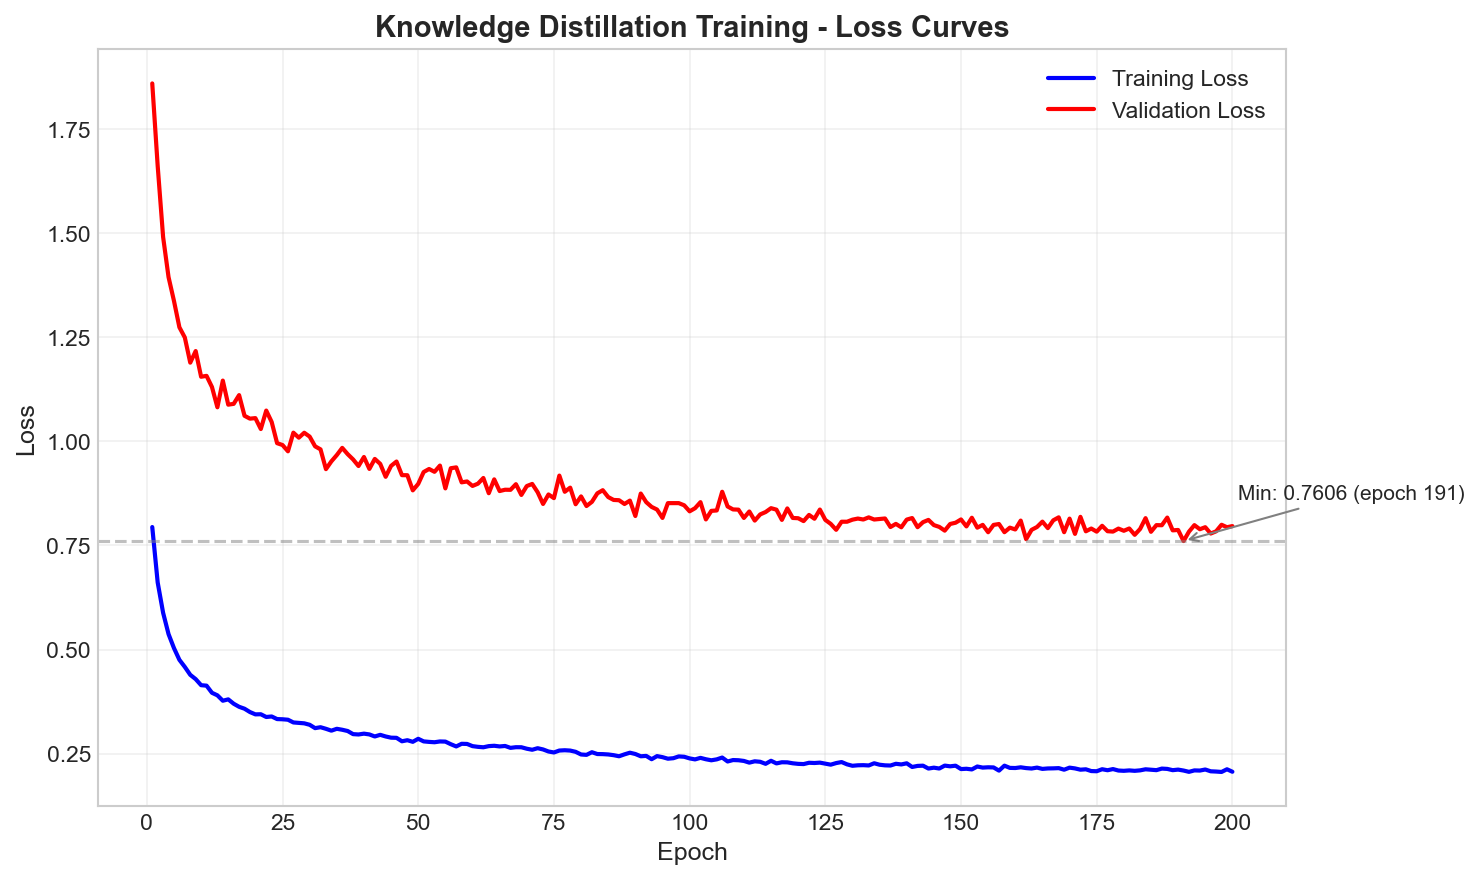

In [22]:
# Plot distillation loss curves
if distill_history:
    plot_loss_curves(distill_history, 'Knowledge Distillation Training',
                     '../weights/visualization/loss_curve_distillation.png')

## 9. Training Curves - Accuracy

In [23]:
def plot_accuracy_curves(history, title, save_path=None):
    """Plot training and validation accuracy curves"""
    if history is None:
        print("No history available")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    epochs = range(1, len(history.get('train_acc', [])) + 1)
    
    if 'train_acc' in history:
        ax.plot(epochs, history['train_acc'], 'b-', linewidth=2, label='Training Accuracy')
    if 'val_acc' in history:
        ax.plot(epochs, history['val_acc'], 'r-', linewidth=2, label='Validation Accuracy')
    if 'test_acc' in history:
        ax.plot(epochs, history['test_acc'], 'g--', linewidth=2, label='Test Accuracy')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'{title} - Accuracy Curves', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add max accuracy annotation
    if 'val_acc' in history:
        max_val_acc = max(history['val_acc'])
        max_epoch = history['val_acc'].index(max_val_acc) + 1
        ax.axhline(y=max_val_acc, color='gray', linestyle='--', alpha=0.5)
        ax.annotate(f'Max: {max_val_acc:.2f}% (epoch {max_epoch})', 
                    xy=(max_epoch, max_val_acc), xytext=(max_epoch - 30, max_val_acc - 3),
                    fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()

# Plot baseline accuracy curves
if baseline_history:
    plot_accuracy_curves(baseline_history, 'Baseline Training',
                         '../weights/visualization/accuracy_curve_baseline.png')

Saved: ../weights/visualization/accuracy_curve_distillation.png


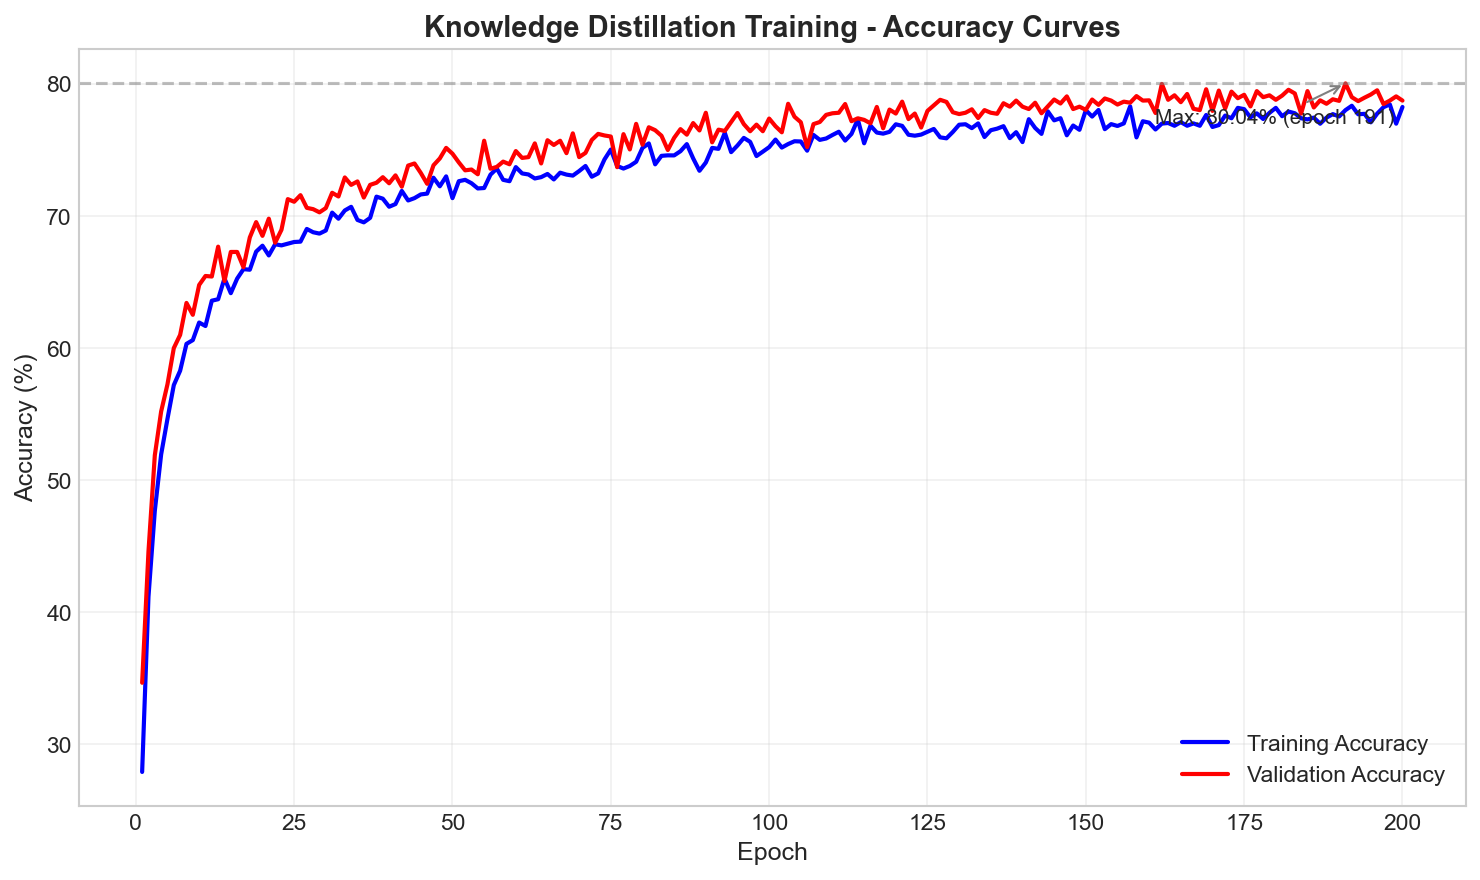

In [24]:
# Plot distillation accuracy curves
if distill_history:
    plot_accuracy_curves(distill_history, 'Knowledge Distillation Training',
                         '../weights/visualization/accuracy_curve_distillation.png')

## 10. Per-Class Accuracy Comparison

Saved: per_class_accuracy.png


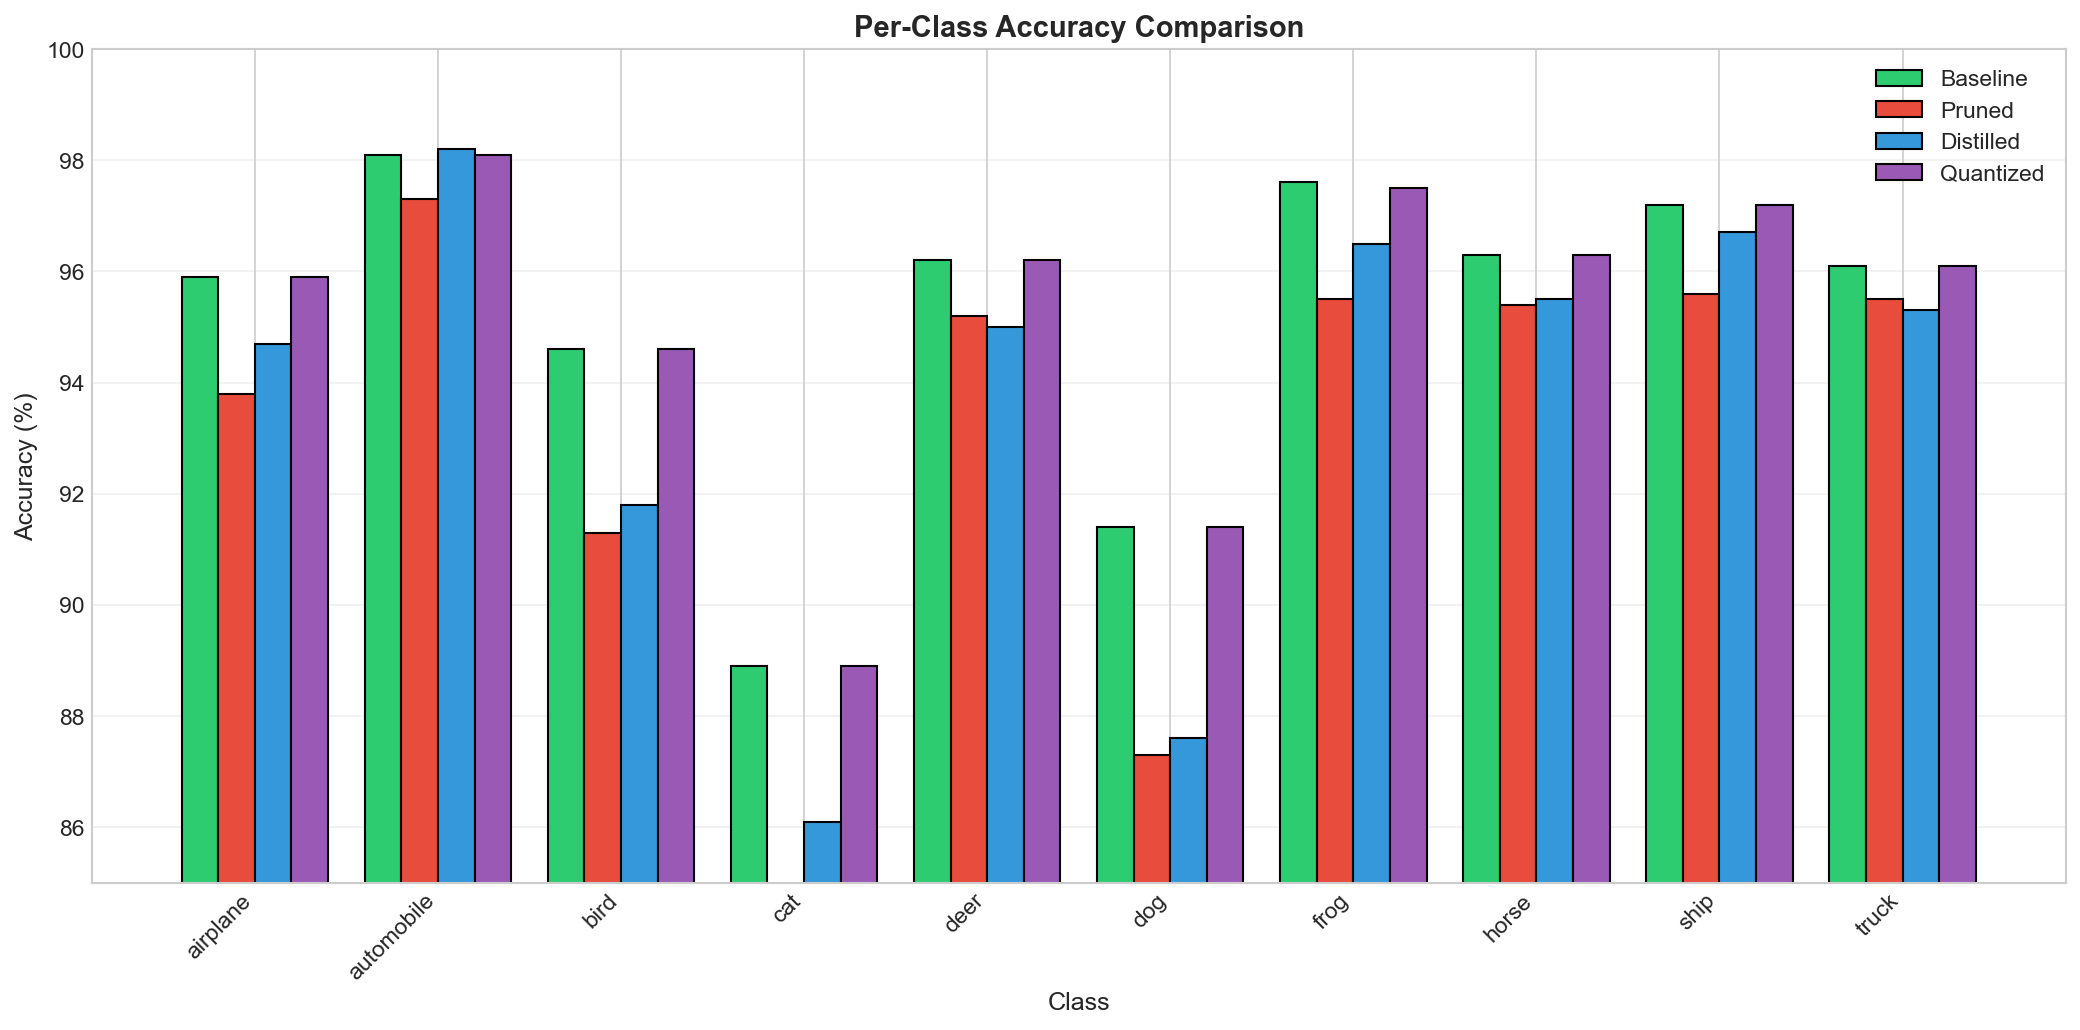

In [25]:
def get_per_class_accuracy(y_true, y_pred, class_names):
    """Calculate per-class accuracy"""
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    return {name: acc for name, acc in zip(class_names, per_class_acc)}

# Calculate per-class accuracy for all models
results = {
    'Baseline': get_per_class_accuracy(labels, baseline_preds, CLASS_NAMES)
}

if 'pruned_preds' in dir():
    results['Pruned'] = get_per_class_accuracy(labels, pruned_preds, CLASS_NAMES)
if 'student_preds' in dir():
    results['Distilled'] = get_per_class_accuracy(labels, student_preds, CLASS_NAMES)
if 'quant_preds' in dir():
    results['Quantized'] = get_per_class_accuracy(labels, quant_preds, CLASS_NAMES)

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(CLASS_NAMES))
width = 0.2
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']

for i, (model_name, class_acc) in enumerate(results.items()):
    accuracies = [class_acc[c] for c in CLASS_NAMES]
    ax.bar(x + i*width, accuracies, width, label=model_name, color=colors[i], edgecolor='black')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (len(results)-1) / 2)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(85, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../weights/visualization/per_class_accuracy.png', dpi=300, bbox_inches='tight')
print("Saved: per_class_accuracy.png")
plt.show()

## 11. Summary Table

In [26]:
import pandas as pd

# Create summary DataFrame
summary_data = []

for model_name, class_acc in results.items():
    row = {'Model': model_name}
    for class_name, acc in class_acc.items():
        row[class_name] = f"{acc:.2f}%"
    row['Average'] = f"{np.mean(list(class_acc.values())):.2f}%"
    summary_data.append(row)

df = pd.DataFrame(summary_data)
print("\nPer-Class Accuracy Summary:")
print("="*100)
print(df.to_string(index=False))


Per-Class Accuracy Summary:
    Model airplane automobile   bird    cat   deer    dog   frog  horse   ship  truck Average
 Baseline   95.90%     98.10% 94.60% 88.90% 96.20% 91.40% 97.60% 96.30% 97.20% 96.10%  95.23%
   Pruned   93.80%     97.30% 91.30% 83.10% 95.20% 87.30% 95.50% 95.40% 95.60% 95.50%  93.00%
Distilled   94.70%     98.20% 91.80% 86.10% 95.00% 87.60% 96.50% 95.50% 96.70% 95.30%  93.74%
Quantized   95.90%     98.10% 94.60% 88.90% 96.20% 91.40% 97.50% 96.30% 97.20% 96.10%  95.22%


## 12. Error Analysis - Most Confused Classes

In [27]:
def analyze_confusion(cm, class_names, top_k=5):
    """Find most confused class pairs"""
    # Exclude diagonal
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    
    # Find top-k confused pairs
    flat_indices = np.argsort(cm_no_diag.flatten())[::-1][:top_k]
    
    print(f"\nTop {top_k} Most Confused Class Pairs:")
    print("-" * 50)
    
    for idx in flat_indices:
        true_class = idx // len(class_names)
        pred_class = idx % len(class_names)
        count = cm_no_diag[true_class, pred_class]
        if count > 0:
            print(f"{class_names[true_class]:12} -> {class_names[pred_class]:12}: {count} samples")

# Analyze baseline confusion
print("\n" + "="*50)
print("BASELINE MODEL ERROR ANALYSIS")
print("="*50)
analyze_confusion(cm_baseline, CLASS_NAMES)


BASELINE MODEL ERROR ANALYSIS

Top 5 Most Confused Class Pairs:
--------------------------------------------------
dog          -> cat         : 56 samples
cat          -> dog         : 54 samples
truck        -> automobile  : 21 samples
airplane     -> ship        : 18 samples
cat          -> deer        : 16 samples


## 13. Save All Results

In [28]:
# Save comprehensive evaluation results
evaluation_results = {
    'models': {},
    'per_class_accuracy': results
}

evaluation_results['models']['baseline'] = {
    'accuracy': float(baseline_acc),
    'confusion_matrix': cm_baseline.tolist()
}

if 'pruned_preds' in dir():
    evaluation_results['models']['pruned'] = {
        'accuracy': float(pruned_acc),
        'confusion_matrix': cm_pruned.tolist()
    }

if 'student_preds' in dir():
    evaluation_results['models']['distilled'] = {
        'accuracy': float(student_acc),
        'confusion_matrix': cm_student.tolist()
    }

if 'quant_preds' in dir():
    evaluation_results['models']['quantized'] = {
        'accuracy': float(quant_acc),
        'confusion_matrix': cm_quant.tolist()
    }

# Save to JSON
with open('../weights/comprehensive_evaluation.json', 'w') as f:
    json.dump(evaluation_results, f, indent=2)

print("Saved comprehensive evaluation to: weights/comprehensive_evaluation.json")

# List all generated visualizations
print("\nGenerated Visualizations:")
print("-" * 40)
viz_dir = Path('../weights/visualization')
for f in sorted(viz_dir.glob('*.png')):
    print(f"  - {f.name}")

Saved comprehensive evaluation to: weights/comprehensive_evaluation.json

Generated Visualizations:
----------------------------------------
  - accuracy_comparison.png
  - accuracy_curve_distillation.png
  - accuracy_vs_params.png
  - compression_radar.png
  - confusion_matrix_baseline.png
  - confusion_matrix_distilled.png
  - confusion_matrix_pruned.png
  - confusion_matrix_quantized.png
  - inference_speed.png
  - latency_comparison.png
  - loss_curve_distillation.png
  - optimization_summary.png
  - params_comparison.png
  - per_class_accuracy.png
